# Results from CNN

1. Imports

In [1]:
import os
import sys
import cv2
import torch
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.metrics import f1_score, confusion_matrix, classification_report
from torch.utils.data import DataLoader
from torchvision import transforms

sys.path.append(os.path.abspath(".."))

from scripts.dataset import PlantVillageDataset

2. Model

In [2]:
import torch.nn as nn

class PlantDiseaseCNN(nn.Module):
    def __init__(self, num_classes, input_size=128, dropout=0.5):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
        )

        with torch.no_grad():
            dummy = torch.zeros(1, 3, input_size, input_size)
            flattened_dim = self.features(dummy).view(1, -1).shape[1]

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(flattened_dim, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(512, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

3. Setting

In [3]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

BASE_DIR = "../raw_data/PlantVillage-Dataset"
SPLIT_CSV = "../data/split.csv"
CLEAN_SPLIT_CSV = "../data/split_notebook_clean.csv"

IMAGE_SIZE = 128
BATCH_SIZE = 64

print("Using device:", DEVICE)

Using device: cuda


4. Just test segmented

In [4]:
split_df = pd.read_csv(SPLIT_CSV)

seg_df = split_df[
    (split_df["split"] == "test") &
    (split_df["data_type"] == "segmented")
].copy()

def is_readable(rel_path, base_dir=BASE_DIR):
    full_path = os.path.join(base_dir, rel_path)
    img = cv2.imread(full_path)
    return img is not None

seg_df["readable"] = seg_df["image_path"].apply(is_readable)

print("Original segmented test rows:", len(seg_df))
print("Readable segmented test rows:", seg_df["readable"].sum())
print("Removed segmented test rows:", len(seg_df) - seg_df["readable"].sum())

seg_df_clean = seg_df[seg_df["readable"]].drop(columns=["readable"]).copy()

split_df_clean = split_df[
    ~((split_df["split"] == "test") & (split_df["data_type"] == "segmented"))
].copy()

split_df_clean = pd.concat([split_df_clean, seg_df_clean], ignore_index=True)
split_df_clean.to_csv(CLEAN_SPLIT_CSV, index=False)

print("Saved cleaned split to:", CLEAN_SPLIT_CSV)

Original segmented test rows: 6401
Readable segmented test rows: 4768
Removed segmented test rows: 1633
Saved cleaned split to: ../data/split_notebook_clean.csv


5. Transforms

In [5]:
transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
])

6. Datasets and dataloaders

In [6]:
label_to_idx = PlantVillageDataset.build_label_mapping(CLEAN_SPLIT_CSV)
idx_to_label = {v: k for k, v in label_to_idx.items()}
num_classes = len(label_to_idx)

test_color = PlantVillageDataset(
    split_csv=CLEAN_SPLIT_CSV,
    split="test",
    data_type="color",
    transform=transform,
    base_dir=BASE_DIR,
    label_to_idx=label_to_idx
)

test_segmented = PlantVillageDataset(
    split_csv=CLEAN_SPLIT_CSV,
    split="test",
    data_type="segmented",
    transform=transform,
    base_dir=BASE_DIR,
    label_to_idx=label_to_idx
)

test_color_loader = DataLoader(test_color, batch_size=BATCH_SIZE, shuffle=False)
test_seg_loader = DataLoader(test_segmented, batch_size=BATCH_SIZE, shuffle=False)

[PlantVillageDataset] split=test, data_type=color, n_images=6401
[PlantVillageDataset] split=test, data_type=segmented, n_images=4768


7. Uploading model

In [7]:
model = PlantDiseaseCNN(num_classes=num_classes).to(DEVICE)
model.load_state_dict(torch.load("../results/custom_cnn/best_custom_cnn.pt", map_location=DEVICE))
model.eval()

print("Model loaded successfully.")

Model loaded successfully.


8. Prediction's model

In [8]:
def get_predictions(model, loader):
    y_true, y_pred = [], []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(DEVICE)
            outputs = model(images)
            preds = outputs.argmax(dim=1)

            y_true.extend(labels.numpy())
            y_pred.extend(preds.cpu().numpy())

    return np.array(y_true), np.array(y_pred)

9. Principal data

In [9]:
y_true_color, y_pred_color = get_predictions(model, test_color_loader)
y_true_seg, y_pred_seg = get_predictions(model, test_seg_loader)

acc_color = (y_true_color == y_pred_color).mean()
acc_seg = (y_true_seg == y_pred_seg).mean()

f1_color = f1_score(y_true_color, y_pred_color, average="macro")
f1_seg = f1_score(y_true_seg, y_pred_seg, average="macro")

print("=== RESULTS ===")
print(f"Color Test     -> Acc: {acc_color:.4f}, Macro-F1: {f1_color:.4f}")
print(f"Segmented Test -> Acc: {acc_seg:.4f}, Macro-F1: {f1_seg:.4f}")

=== RESULTS ===
Color Test     -> Acc: 0.9597, Macro-F1: 0.9441
Segmented Test -> Acc: 0.4706, Macro-F1: 0.3040


10. Summary

In [10]:
results_df = pd.DataFrame({
    "Model": ["Custom CNN"],
    "Color Accuracy": [acc_color],
    "Color Macro-F1": [f1_color],
    "Segmented Accuracy": [acc_seg],
    "Segmented Macro-F1": [f1_seg],
})

results_df

,Model,Color Accuracy,Color Macro-F1,Segmented Accuracy,Segmented Macro-F1
0,Custom CNN,0.959694,0.944117,0.470638,0.304038


11. Confusion matrix

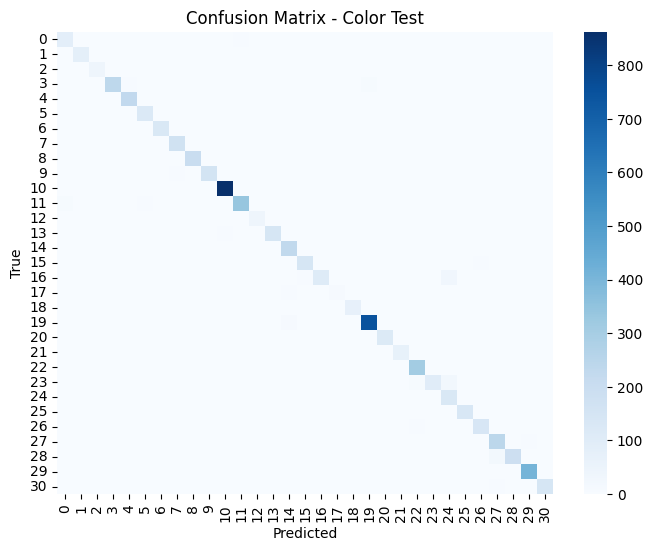

In [11]:
cm_color = confusion_matrix(y_true_color, y_pred_color)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_color, cmap="Blues")
plt.title("Confusion Matrix - Color Test")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

12. Confusion matrix- segmented data

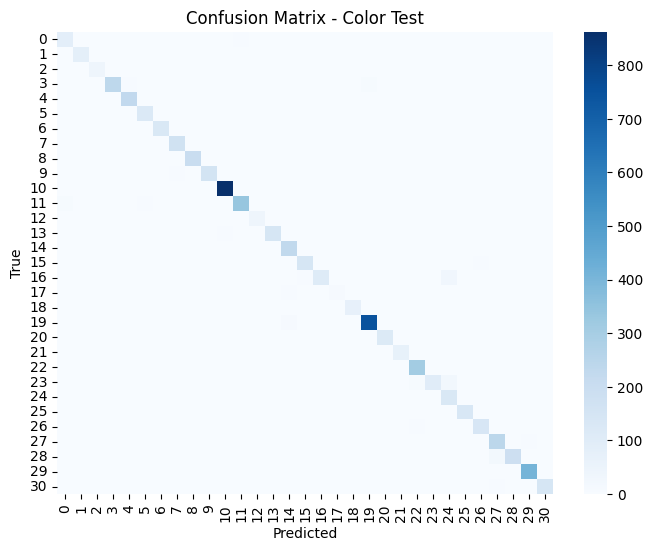

In [12]:
cm_color = confusion_matrix(y_true_color, y_pred_color)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_color, cmap="Blues")
plt.title("Confusion Matrix - Color Test")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

13. Classification report color

In [13]:
print("=== COLOR REPORT ===")
print(classification_report(y_true_color, y_pred_color, zero_division=0))

=== COLOR REPORT ===
              precision    recall  f1-score   support

           0       0.88      0.96      0.91        89
           1       1.00      0.98      0.99        85
           2       0.93      1.00      0.96        40
           3       0.98      0.95      0.96       250
           4       0.98      0.99      0.98       229
           5       0.96      0.97      0.96       127
           6       0.98      0.98      0.98       130
           7       0.96      0.97      0.96       176
           8       0.99      0.99      0.99       208
           9       0.99      0.96      0.97       164
          10       0.99      1.00      1.00       862
          11       0.98      0.96      0.97       353
          12       1.00      1.00      1.00        42
          13       0.93      0.95      0.94       149
          14       0.93      0.98      0.95       233
          15       0.97      0.97      0.97       148
          16       0.99      0.74      0.85       148
      

14. Classification report segmented

In [14]:
print("=== COLOR REPORT ===")
print(classification_report(y_true_color, y_pred_color, zero_division=0))

=== COLOR REPORT ===
              precision    recall  f1-score   support

           0       0.88      0.96      0.91        89
           1       1.00      0.98      0.99        85
           2       0.93      1.00      0.96        40
           3       0.98      0.95      0.96       250
           4       0.98      0.99      0.98       229
           5       0.96      0.97      0.96       127
           6       0.98      0.98      0.98       130
           7       0.96      0.97      0.96       176
           8       0.99      0.99      0.99       208
           9       0.99      0.96      0.97       164
          10       0.99      1.00      1.00       862
          11       0.98      0.96      0.97       353
          12       1.00      1.00      1.00        42
          13       0.93      0.95      0.94       149
          14       0.93      0.98      0.95       233
          15       0.97      0.97      0.97       148
          16       0.99      0.74      0.85       148
      

### Results Summary

The custom CNN achieved strong in-distribution performance on the color test set, with high accuracy and macro-F1. However, performance dropped substantially on the segmented test set, showing reduced robustness under distribution shift. This supports the project hypothesis that strong performance on the original image distribution does not necessarily imply strong generalization to shifted image representations.